In [19]:
import numpy as np
import pandas as pd
import optuna
from sklearn.preprocessing import MinMaxScaler
import xgboost

from utils import encode_features, get_train_test_data, train_model, evaluate_model, generate_individual, epsilon_rounding, get_relevant_candidates

optuna.logging.set_verbosity(optuna.logging.WARNING)

## Data

In [20]:
def load_data(data_filepath="data/Loan_data_extracted.csv"):
    """
    Input: path to .csv data file
    
    TODO: specify in feature_info whether features are of type:
        fixed, meaning cannot change for the counterfactual
        unique, meaning can only take existing categorical values
        increase, meaning their value can only increase and not decrease
        range, meaning their new value can take a range of values

    Returns:
        dataframe and feature configuration dictionary
    """
    df = pd.read_csv(data_filepath)
    df = df.drop('Loan_ID', axis=1)
    df = df.dropna()
    
    feature_config = {
        "categorical": ["Gender", "Married", "Education", "Self_Employed", "Property_Area", "Loan_Status"],
    
        "feature_info": [
            ('Gender', 'fixed'),
            ('Married', 'unique'),
            ('Dependents', 'fixed'),
            ('Education', 'increase'),
            ('Self_Employed', 'unique'),
            ('ApplicantIncome', 'range'),
            ('CoapplicantIncome', 'range'),
            ('LoanAmount', 'fixed'),
            ('Loan_Amount_Term', 'unique'),
            ('Credit_History', 'unique'),
            ('Property_Area', 'unique'),
        ],
    
        "categorical_features": ["Gender", "Married", "Education", "Self_Employed", "Property_Area"]
    }

    return df, feature_config

## Model

In [21]:
# Load the model from the saved file
model = xgboost.XGBClassifier()
model.load_model("xgboost_model.json")

## Counterfactual search

In [22]:
def misfit(x_prime, y_target, model):
  """
  Optimisation criterion 1
  Calculate absolute difference between y_target and y_prime_prediction.
  """
  y_prob = model.predict_proba(x_prime)[:, 1][0]
  diff = abs(y_target - y_prob)

  return diff

In [23]:
def distance(X, x, x_prime, numerical, categorical):
  """
  Optimisation criterion 2
  Calculate distance between x_prime and x.
  """
  # Normalize data
  scaler = MinMaxScaler()
  scaler.fit(X[numerical])
  x_normalized = scaler.transform(x[numerical])
  x_prime_normalized = scaler.transform(x_prime[numerical])

  # Compute distances
  dist_num = np.sum(np.abs(x_normalized - x_prime_normalized))
  dist_cat = np.sum(x[categorical].values != x_prime[categorical].values)

  total_features = len(numerical) + len(categorical)

  total_dist = (dist_num + dist_cat) / total_features

  return total_dist

In [24]:
def sparsity(x, x_prime):
  """
  Optimisation criterion 3
  Return number of unchanged features.
  """
  matches = (x.values == x_prime.values)
  unchanged = np.sum(matches)

  return unchanged

In [25]:
def closest_real(X, x_prime, categorical, numerical):
  """
  Optimisation criterion 4
  Return the minimum distance between x_prime and any point in X.
  """
  scaler = MinMaxScaler()
  X_normalized = scaler.fit_transform(X[numerical])
  x_prime_normalized = scaler.transform(x_prime[numerical])

  # Compute total distance
  dist_num = np.sum(np.abs(X_normalized - x_prime_normalized), axis=1)
  dist_cat = np.sum(X[categorical].values != x_prime[categorical].values, axis=1)

  total_features = len(numerical) + len(categorical)

  total_dist = (dist_num + dist_cat) / total_features

  min_dist = np.min(total_dist)

  return min_dist

In [26]:
def objective(trial, X, x, features, model, y_target, numerical, categorical):
    x_prime = x.copy()
    for feature in features:
        feature.sample(trial)
        x_prime[feature.name] = feature.value
    epsilon_rounding(x, x_prime, 1e-1)

    obj1 = misfit(x_prime, y_target, model)
    obj2 = distance(X, x, x_prime, numerical, categorical)
    obj3 = sparsity(x, x_prime)
    obj4 = closest_real(X, x_prime, categorical, numerical)

    return obj1, obj2, obj3, obj4

In [42]:
def get_counterfactuals(X, x, y_target, model, 
                        numerical, categorical, features, 
                        tol, optimization_steps, timeout):

    study = optuna.create_study(directions=['minimize', 'minimize', 'maximize', 'minimize'], 
                                sampler=optuna.samplers.NSGAIISampler(seed=42)) 
    
    study.optimize(lambda trial: objective(trial, X, x, features, model, 
                                           y_target, 
                                           numerical, 
                                           categorical), 
                   n_trials=optimization_steps, 
                   timeout=timeout)
    
    candidates_df = get_relevant_candidates(study, x, model, y_target, tol)
    
    return candidates_df, study

## Provided datapoint and data

In [28]:
X_obs, feat_conf = load_data("../data/Loan_data_extracted.csv")
X_obs = encode_features(X_obs, feat_conf["categorical"])

--- 
Encoded categorical features as follows:
Gender :  {'Female': 0, 'Male': 1}
Married :  {'No': 0, 'Yes': 1}
Education :  {'Not Graduate': 0, 'Graduate': 1}
Self_Employed :  {'No': 0, 'Yes': 1}
Property_Area :  {'Rural': 0, 'Semiurban': 1, 'Urban': 2}
Loan_Status :  {'N': 0, 'Y': 1}
---


In [29]:
customer = np.array([0,1,0,0,0,2000,1500,1000,480,0,1])
x = pd.DataFrame([customer], columns=X_obs.columns[:-1].tolist())

In [30]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0,1,0,0,0,2000,1500,1000,480,0,1


In [31]:
# Check that our customer x did not get the loan
# and help her find out what she has to do in order to get the loan
# If you have implemented everything above correctly, the code below
# will find the counterfactuals

y_prob = model.predict_proba(x)[:, 1][0]
y_pred = model.predict(x)[0]

print(f"Predicted probability of getting Load: {y_prob:.4f}")
print(f"Predicted Class: {y_pred}")

Predicted probability of getting Load: 0.0030
Predicted Class: 0


In [32]:
X_train = X_obs.drop("Loan_Status", axis=1)
y_target = 1.0 # Get the load

cat_cols = feat_conf["categorical_features"]
num_cols = [col for col in X_train.columns if col not in cat_cols]

features = generate_individual(X_train,x,feat_conf["feature_info"])

In [43]:
counterfactuals, study = get_counterfactuals(
    X=X_train,
    x=x,
    y_target=y_target,
    model=model,
    numerical=num_cols,
    categorical=cat_cols,
    features=features,
    tol=0.05,
    optimization_steps=500,
    timeout=60
)

In [44]:
counterfactuals

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.0,1.0,0.0,1.0,0.0,8679.352223,194.852546,1000.0,360.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,11138.690842,772.817051,1000.0,360.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,4425.334868,113.404357,1000.0,360.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,3311.489898,113.404357,1000.0,360.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,2968.822162,113.404357,1000.0,360.0,0.0,1.0
5,0.0,1.0,0.0,1.0,0.0,4119.538579,123.794291,1000.0,360.0,0.0,1.0
6,0.0,1.0,0.0,0.0,0.0,11138.690842,113.404357,1000.0,360.0,0.0,1.0
7,0.0,1.0,0.0,0.0,0.0,9996.867467,194.852546,1000.0,360.0,0.0,1.0
8,0.0,1.0,0.0,0.0,0.0,9830.738499,123.794291,1000.0,360.0,0.0,1.0
9,0.0,1.0,0.0,0.0,0.0,3082.647900,1385.262491,1000.0,360.0,0.0,1.0


## Search for counterfactuals

In [45]:
# Make a list of Feature objects containing information about how 
# each feature is allowed to change when generating counterfactuals
change_features = generate_individual(X_obs, x, feat_conf["feature_info"])

In [46]:
# Set the desired new model prediction
y_CF = 0.7
print(f"Searching for counterfactuals with y_CF = {y_CF}...\n")
numerical_features = [x for x in x.columns if x not in feat_conf["categorical"]]
CFS = get_counterfactuals(X_obs, x, y_CF, model,
                          numerical_features,
                          feat_conf["categorical_features"],
                          change_features,
                          tol=0.05,
                          optimization_steps=500,
                          timeout=None)

Searching for counterfactuals with y_CF = 0.7...



In [47]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0,1,0,0,0,2000,1500,1000,480,0,1


In [48]:
CFS

(Empty DataFrame
 Columns: [Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area]
 Index: [],
 <optuna.study.study.Study at 0x7cd7140771a0>)

In [49]:
def extract_objectives(study):
    records = []
    for t in study.best_trials:
        obj1, obj2, obj3, obj4 = t.values
        records.append({
            "misfit": obj1,
            "distance": obj2,
            "sparsity": obj3,
            "realism": obj4
        })
    return pd.DataFrame(records)

In [50]:
obj_df = extract_objectives(study)
obj_df

,misfit,distance,sparsity,realism
0,0.027199,0.292687,6.0,0.212124
1,0.031375,0.349900,6.0,0.154911
2,0.890782,0.125241,8.0,0.379570
3,0.012235,0.294806,7.0,0.391823
4,0.007174,0.383596,5.0,0.303033
...,...,...,...,...
154,0.966340,0.100730,8.0,0.404081
155,0.003460,0.439999,5.0,0.246630
156,0.072351,0.170417,7.0,0.334394
157,0.978689,0.101294,8.0,0.403517


In [52]:
import matplotlib.pyplot as plt

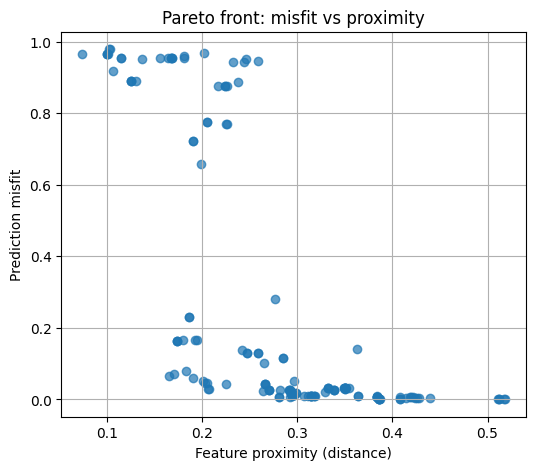

In [53]:
plt.figure(figsize=(6,5))
plt.scatter(obj_df["distance"], obj_df["misfit"], alpha=0.7)
plt.xlabel("Feature proximity (distance)")
plt.ylabel("Prediction misfit")
plt.title("Pareto front: misfit vs proximity")
plt.grid(True)
plt.show()

In the above plot, each point corresponds to one candidate counterfactual, the x-axis indicates how muchthe counterfactual differs from the original instance and the y-axis indicates how far the model's prediction for the counterfactual is from the desired outcome.

- The bottom-right region of the plot contains counterfactuals with low misfit, the model strongly predicts the desired outcome, but large feature changes.
- The upper-left region contains counterfactuals that are close to the original input, but they fail to reach the target prediciton.

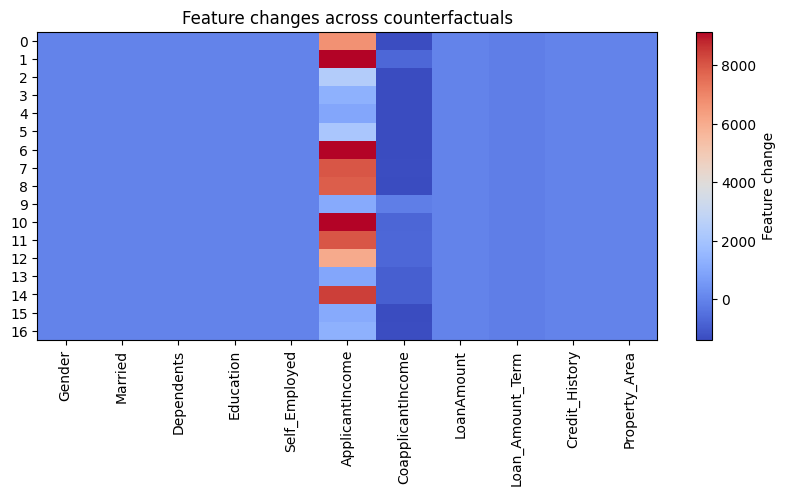

In [54]:
def feature_change_heatmap(x, counterfactuals):
    diffs = counterfactuals.copy()
    for col in diffs.columns:
        diffs[col] = diffs[col] - x[col].values[0]

    plt.figure(figsize=(10,4))
    plt.imshow(diffs.values, aspect="auto", cmap="coolwarm")
    plt.colorbar(label="Feature change")
    plt.yticks(range(len(diffs)), diffs.index)
    plt.xticks(range(len(diffs.columns)), diffs.columns, rotation=90)
    plt.title("Feature changes across counterfactuals")
    plt.show()

feature_change_heatmap(x, counterfactuals)

The heatmap visualize how individual features change across different counterfactuals.
- Rows: different counterfactuals
- Columns: Input features
- Color: magnitude and direction of change (Blue: little or no change, Red: Large increase, Dark blue: large decrease)


From the plot we can see that:
- ApplicantIncome shows large changes across counterfactuals, this indicate that increasing income is a dominant strategy for getting load approval.
- CoapplicantIncome also changes, but less than the ApplicantIncome
- Most categorial or constrained features remain unchanged, this indicates the actionability constraints.